# Investigação de Fraudes em Transações de Cartão

Análise exploratória e comportamental de transações contestadas, buscando identificar padrões atípicos, concentrações de fraude e desvios em relação ao histórico transacional dos clientes.

**Objetivo:** identificar comportamentos potencialmente fraudulentos e desenvolver uma regra de decisão para ressarcimento baseada no perfil histórico de cada cliente.

**Principais abordagens utilizadas:** análise exploratória com a criação e interpretação de indicadores, cruzamento de bases de dados, análise temporal, segmentação de clientes, definição de perfil transacional utilizando P90, P99 e regras de decisão.

## 1. Carregamento e Inspeção Inicial dos Dados

Importação das bases e análise inicial de estrutura, volume, tipos de dados e granularidade.

In [1]:
# Bibliotecas utilizadas no projeto.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec

In [2]:
Base_dados = pd.read_csv('base_1_contestacoes.csv')

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente
0,45638970274,NaN,Conta Corrente,Conta Corrente,2026-02-13,925.62,2026-02-12,05:50:00,Pix indevido,CC100364,Private,Online,42,Sul,SC,NaN,NaN
1,28034576107,4.740136e+15,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet
2,42195670894,NaN,Conta Corrente,Conta Corrente,2026-05-03,727.79,2026-05-03,15:30:00,Pix indevido,CC100278,Varejo,Online,49,Sudeste,SP,NaN,NaN
3,91375026461,NaN,Conta Corrente,Conta Corrente,2026-03-11,1246.34,2026-03-08,08:17:00,Boleto falso,CC100391,Private,Online,60,Sul,PR,NaN,NaN
4,20135649706,NaN,Conta Corrente,Conta Corrente,2026-01-17,1686.10,2026-01-14,22:30:00,Transferência não reconhecida,CC100436,Personnalité,Online,38,Centro-Oeste,DF,NaN,NaN
5,48936517066,NaN,Conta Corrente,Conta Corrente,2026-05-31,971.70,2026-05-28,13:29:00,Transferência não reconhecida,CC100290,Varejo,Online,18,Sudeste,ES,NaN,NaN
6,36598712491,NaN,Conta Corrente,Conta Corrente,2026-01-08,1846.62,2026-01-07,12:00:00,Pix indevido,CC100218,Varejo,Online,43,Sudeste,RJ,NaN,NaN
7,1368497250,4.325757e+15,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,Private,Online,27,Sul,SC,Eletrônicos Y,Getnet
8,17485039601,NaN,Conta Corrente,Conta Corrente,2026-01-13,2025.55,2026-01-10,09:11:00,Boleto falso,CC100433,Varejo,Online,35,Centro-Oeste,GO,NaN,NaN
9,79043162507,NaN,Conta Corrente,Conta Corrente,2026-05-19,2299.85,2026-05-16,15:36:00,Transferência não reconhecida,CC100403,Personnalité,Online,32,Nordeste,PB,NaN,NaN


In [3]:
Base_dados.shape

(456, 17)

In [4]:
Base_dados['cpf'].count()

np.int64(456)

In [5]:
# Conta se existem campos com duplicidade
# Indica alta granularidade já que a chave primaria se repete
Base_dados['cpf'].nunique()

360

In [6]:
Base_dados['numero_ticket'].count()

np.int64(456)

In [7]:
Base_dados['numero_ticket'].nunique()

456

In [8]:
Base_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cpf                         456 non-null    int64  
 1   cartao                      123 non-null    float64
 2   produto                     456 non-null    object 
 3   tipo_conta                  456 non-null    object 
 4   data_contestacao            456 non-null    object 
 5   transacao_contestada_valor  456 non-null    float64
 6   data_transacao              456 non-null    object 
 7   hora_transacao              456 non-null    object 
 8   modalidade_fraude           456 non-null    object 
 9   numero_ticket               456 non-null    object 
 10  segmento                    456 non-null    object 
 11  tipo_transacao              456 non-null    object 
 12  idade                       456 non-null    int64  
 13  regiao                      456 non

In [9]:
# Importando a Base 2 relatos
Base_relatos = pd.read_csv('base_2_relatos.csv')

Base_relatos.head(10)

,numero_ticket,relato_cliente,canal_abertura
0,TK100078,Não autorizei essa cobrança recorrente e não r...,Central
1,TK100082,Não reconheço essa compra no meu cartão e não ...,Internet Banking
2,TK100075,Recebi a notificação de uma compra que desconh...,Internet Banking
3,TK100076,Não reconheço essa compra no meu cartão e não ...,Agência
4,TK100073,A cobrança apareceu novamente e eu não autorizei.,Internet Banking
5,TK100009,Acredito que os dados do meu cartão foram clon...,Chat
6,TK100030,Recebi uma mensagem suspeita e depois identifi...,Central
7,TK100104,Acredito que os dados do meu cartão foram clon...,App
8,TK100070,"Meu cartão estava comigo, mas apareceram compr...",Internet Banking
9,TK100055,Cliquei em um link recebido por mensagem e dep...,Agência


In [10]:
Base_relatos.shape

(130, 3)

In [11]:
Base_relatos['numero_ticket'].count()

np.int64(130)

In [12]:
# Conta se existem campos com duplicidade
# Indica alta granularidade já que a chave primaria se repete
Base_relatos['numero_ticket'].nunique()

118

In [13]:
# Importando Base 3 transacional
Base_transacional = pd.read_csv('base_3_transacional.csv')

Base_transacional.head(10)

,cpf_em_texto_14,cartao_mascarado,data,hora,valor,estabelecimento,ramo,tipo_transacao,adquirente,status
0,721.943.850-88,424533******0697,2026-02-01,05:22:09,19.16,Mercado Livre,E-commerce,Online,Cielo,Aprovada
1,537.428.190-97,453898******4144,2026-03-07,18:45:45,94.82,iFood,Alimentação,Presencial,Rede,Aprovada
2,043.967.281-31,473390******0775,2026-03-07,13:55:26,32.36,iFood,Alimentação,Presencial,Cielo,Aprovada
3,506.139.248-51,412633******0764,2026-02-17,19:07:15,63.29,Eletrônicos Y,Tecnologia,Presencial,Getnet,Aprovada
4,347.982.560-56,478087******4524,2026-05-09,09:02:53,69.06,Amazon BR,E-commerce,Presencial,Cielo,Aprovada
5,795.648.231-37,490062******3964,2026-02-09,20:07:31,76.89,Spotify,Assinaturas,Presencial,Cielo,Aprovada
6,468.752.309-92,477272******5181,2026-03-20,23:41:42,144.46,Renner,Varejo,Online,PagSeguro,Aprovada
7,081.946.375-20,425345******9728,2026-04-01,04:34:25,83.17,Google,Tecnologia,Presencial,Getnet,Negada
8,985.347.216-37,431328******6820,2026-01-08,19:00:02,61.44,Eletrônicos Y,Tecnologia,Presencial,Getnet,Aprovada
9,260.185.497-94,434095******8960,2026-02-20,00:49:38,27.41,Mercado Livre,E-commerce,Presencial,Rede,Aprovada


In [14]:
Base_transacional.shape

(26035, 10)

In [15]:
# Verificando campos unicos
Base_transacional['cpf_em_texto_14'].count()

np.int64(26035)

In [16]:
# Conta se existem campos com duplicidade
# Indica alta granularidade já que a chave primaria se repete
Base_transacional['cpf_em_texto_14'].nunique()

900

## 2. Limpeza, Padronização e Integração dos Dados

Tratamento e padronização das chaves de identificação, preparação das bases e integração das informações por meio dos cruzamentos necessários para a análise.

In [17]:
# Covertendo cpf para string da base_1_contestacoes
Base_dados['cpf'] = Base_dados['cpf'].astype(str).str.replace(r'\D', '', regex=True)

Base_dados.head()

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente
0,45638970274,NaN,Conta Corrente,Conta Corrente,2026-02-13,925.62,2026-02-12,05:50:00,Pix indevido,CC100364,Private,Online,42,Sul,SC,NaN,NaN
1,28034576107,4.740136e+15,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet
2,42195670894,NaN,Conta Corrente,Conta Corrente,2026-05-03,727.79,2026-05-03,15:30:00,Pix indevido,CC100278,Varejo,Online,49,Sudeste,SP,NaN,NaN
3,91375026461,NaN,Conta Corrente,Conta Corrente,2026-03-11,1246.34,2026-03-08,08:17:00,Boleto falso,CC100391,Private,Online,60,Sul,PR,NaN,NaN
4,20135649706,NaN,Conta Corrente,Conta Corrente,2026-01-17,1686.10,2026-01-14,22:30:00,Transferência não reconhecida,CC100436,Personnalité,Online,38,Centro-Oeste,DF,NaN,NaN


In [18]:
# Covertendo cpf para string da base_3_transacional
Base_transacional['cpf_em_texto_14'] = Base_transacional['cpf_em_texto_14'].astype(str).str.replace(r'\D', '', regex=True)

Base_transacional.head()

,cpf_em_texto_14,cartao_mascarado,data,hora,valor,estabelecimento,ramo,tipo_transacao,adquirente,status
0,72194385088,424533******0697,2026-02-01,05:22:09,19.16,Mercado Livre,E-commerce,Online,Cielo,Aprovada
1,53742819097,453898******4144,2026-03-07,18:45:45,94.82,iFood,Alimentação,Presencial,Rede,Aprovada
2,04396728131,473390******0775,2026-03-07,13:55:26,32.36,iFood,Alimentação,Presencial,Cielo,Aprovada
3,50613924851,412633******0764,2026-02-17,19:07:15,63.29,Eletrônicos Y,Tecnologia,Presencial,Getnet,Aprovada
4,34798256056,478087******4524,2026-05-09,09:02:53,69.06,Amazon BR,E-commerce,Presencial,Cielo,Aprovada


In [19]:
# Convertendo cartao para string da base_1_contestacoes
Base_dados['cartao'] = Base_dados['cartao'].astype(str).str.replace(r'\D', '', regex=True)

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente
0,45638970274,,Conta Corrente,Conta Corrente,2026-02-13,925.62,2026-02-12,05:50:00,Pix indevido,CC100364,Private,Online,42,Sul,SC,NaN,NaN
1,28034576107,47401363348077790,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet
2,42195670894,,Conta Corrente,Conta Corrente,2026-05-03,727.79,2026-05-03,15:30:00,Pix indevido,CC100278,Varejo,Online,49,Sudeste,SP,NaN,NaN
3,91375026461,,Conta Corrente,Conta Corrente,2026-03-11,1246.34,2026-03-08,08:17:00,Boleto falso,CC100391,Private,Online,60,Sul,PR,NaN,NaN
4,20135649706,,Conta Corrente,Conta Corrente,2026-01-17,1686.10,2026-01-14,22:30:00,Transferência não reconhecida,CC100436,Personnalité,Online,38,Centro-Oeste,DF,NaN,NaN
5,48936517066,,Conta Corrente,Conta Corrente,2026-05-31,971.70,2026-05-28,13:29:00,Transferência não reconhecida,CC100290,Varejo,Online,18,Sudeste,ES,NaN,NaN
6,36598712491,,Conta Corrente,Conta Corrente,2026-01-08,1846.62,2026-01-07,12:00:00,Pix indevido,CC100218,Varejo,Online,43,Sudeste,RJ,NaN,NaN
7,1368497250,43257573463888790,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,Private,Online,27,Sul,SC,Eletrônicos Y,Getnet
8,17485039601,,Conta Corrente,Conta Corrente,2026-01-13,2025.55,2026-01-10,09:11:00,Boleto falso,CC100433,Varejo,Online,35,Centro-Oeste,GO,NaN,NaN
9,79043162507,,Conta Corrente,Conta Corrente,2026-05-19,2299.85,2026-05-16,15:36:00,Transferência não reconhecida,CC100403,Personnalité,Online,32,Nordeste,PB,NaN,NaN


In [20]:
# Criando uma nova coluna "carta_mascarado" para poder cruzar
Base_dados['cartao_mascarado'] = Base_dados['cartao'].astype(str).apply(
    lambda x: x[:6] + '*' * (len(x) - 10) + x[-4:]
)

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente,cartao_mascarado
0,45638970274,,Conta Corrente,Conta Corrente,2026-02-13,925.62,2026-02-12,05:50:00,Pix indevido,CC100364,Private,Online,42,Sul,SC,NaN,NaN,
1,28034576107,47401363348077790,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet,474013*******7790
2,42195670894,,Conta Corrente,Conta Corrente,2026-05-03,727.79,2026-05-03,15:30:00,Pix indevido,CC100278,Varejo,Online,49,Sudeste,SP,NaN,NaN,
3,91375026461,,Conta Corrente,Conta Corrente,2026-03-11,1246.34,2026-03-08,08:17:00,Boleto falso,CC100391,Private,Online,60,Sul,PR,NaN,NaN,
4,20135649706,,Conta Corrente,Conta Corrente,2026-01-17,1686.10,2026-01-14,22:30:00,Transferência não reconhecida,CC100436,Personnalité,Online,38,Centro-Oeste,DF,NaN,NaN,
5,48936517066,,Conta Corrente,Conta Corrente,2026-05-31,971.70,2026-05-28,13:29:00,Transferência não reconhecida,CC100290,Varejo,Online,18,Sudeste,ES,NaN,NaN,
6,36598712491,,Conta Corrente,Conta Corrente,2026-01-08,1846.62,2026-01-07,12:00:00,Pix indevido,CC100218,Varejo,Online,43,Sudeste,RJ,NaN,NaN,
7,1368497250,43257573463888790,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,Private,Online,27,Sul,SC,Eletrônicos Y,Getnet,432575*******8790
8,17485039601,,Conta Corrente,Conta Corrente,2026-01-13,2025.55,2026-01-10,09:11:00,Boleto falso,CC100433,Varejo,Online,35,Centro-Oeste,GO,NaN,NaN,
9,79043162507,,Conta Corrente,Conta Corrente,2026-05-19,2299.85,2026-05-16,15:36:00,Transferência não reconhecida,CC100403,Personnalité,Online,32,Nordeste,PB,NaN,NaN,


In [21]:
# Conferindo tipo
Base_dados[['cpf', 'cartao', 'cartao_mascarado']].dtypes

,0
cpf,object
cartao,object
cartao_mascarado,object


In [22]:
# Conferindo tipo
Base_transacional[['cpf_em_texto_14']].dtypes

,0
cpf_em_texto_14,object


In [23]:
# Verificando campos nulos nas chaves primarias
Base_dados[['cpf', 'cartao', 'cartao_mascarado']].isnull().sum()

,0
cpf,0
cartao,0
cartao_mascarado,0


In [24]:
# Verificando campos nulos nas chaves primarias
Base_transacional[['cpf_em_texto_14', 'cartao_mascarado']].isnull().sum()

,0
cpf_em_texto_14,0
cartao_mascarado,0


In [25]:
Base_dados[
    (~Base_dados['cpf'].str.fullmatch(r'\d{11}', na=False)) |
    (~Base_dados['cartao_mascarado'].str.fullmatch(r'\d{6}\*+\d{4}', na=False))
][['cpf', 'cartao_mascarado']]

,cpf,cartao_mascarado
0,45638970274,
2,42195670894,
3,91375026461,
4,20135649706,
5,48936517066,
...,...,...
448,46718293555,
450,51208347608,
451,80621549398,
453,64783921555,


In [26]:
Base_dados[
    ~Base_dados['cpf'].str.fullmatch(r'\d{11}', na=False)
][['cpf']]

,cpf
7,1368497250
18,3896451766
31,3896451766
48,5984326710
49,3297481650
64,9176482340
65,5628947130
94,4798216313
100,4813957684
120,7241538617


In [27]:
# Deixando todos cpf com 11 digitos
Base_dados['cpf'] = Base_dados['cpf'].astype(str).str.zfill(11)

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente,cartao_mascarado
0,45638970274,,Conta Corrente,Conta Corrente,2026-02-13,925.62,2026-02-12,05:50:00,Pix indevido,CC100364,Private,Online,42,Sul,SC,NaN,NaN,
1,28034576107,47401363348077790,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet,474013*******7790
2,42195670894,,Conta Corrente,Conta Corrente,2026-05-03,727.79,2026-05-03,15:30:00,Pix indevido,CC100278,Varejo,Online,49,Sudeste,SP,NaN,NaN,
3,91375026461,,Conta Corrente,Conta Corrente,2026-03-11,1246.34,2026-03-08,08:17:00,Boleto falso,CC100391,Private,Online,60,Sul,PR,NaN,NaN,
4,20135649706,,Conta Corrente,Conta Corrente,2026-01-17,1686.10,2026-01-14,22:30:00,Transferência não reconhecida,CC100436,Personnalité,Online,38,Centro-Oeste,DF,NaN,NaN,
5,48936517066,,Conta Corrente,Conta Corrente,2026-05-31,971.70,2026-05-28,13:29:00,Transferência não reconhecida,CC100290,Varejo,Online,18,Sudeste,ES,NaN,NaN,
6,36598712491,,Conta Corrente,Conta Corrente,2026-01-08,1846.62,2026-01-07,12:00:00,Pix indevido,CC100218,Varejo,Online,43,Sudeste,RJ,NaN,NaN,
7,01368497250,43257573463888790,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,Private,Online,27,Sul,SC,Eletrônicos Y,Getnet,432575*******8790
8,17485039601,,Conta Corrente,Conta Corrente,2026-01-13,2025.55,2026-01-10,09:11:00,Boleto falso,CC100433,Varejo,Online,35,Centro-Oeste,GO,NaN,NaN,
9,79043162507,,Conta Corrente,Conta Corrente,2026-05-19,2299.85,2026-05-16,15:36:00,Transferência não reconhecida,CC100403,Personnalité,Online,32,Nordeste,PB,NaN,NaN,


In [28]:
# Deixando todos cpf com 11 digitos
Base_transacional['cpf_em_texto_14'] = Base_transacional['cpf_em_texto_14'].astype(str).str.zfill(11)

Base_transacional.head(10)

,cpf_em_texto_14,cartao_mascarado,data,hora,valor,estabelecimento,ramo,tipo_transacao,adquirente,status
0,72194385088,424533******0697,2026-02-01,05:22:09,19.16,Mercado Livre,E-commerce,Online,Cielo,Aprovada
1,53742819097,453898******4144,2026-03-07,18:45:45,94.82,iFood,Alimentação,Presencial,Rede,Aprovada
2,04396728131,473390******0775,2026-03-07,13:55:26,32.36,iFood,Alimentação,Presencial,Cielo,Aprovada
3,50613924851,412633******0764,2026-02-17,19:07:15,63.29,Eletrônicos Y,Tecnologia,Presencial,Getnet,Aprovada
4,34798256056,478087******4524,2026-05-09,09:02:53,69.06,Amazon BR,E-commerce,Presencial,Cielo,Aprovada
5,79564823137,490062******3964,2026-02-09,20:07:31,76.89,Spotify,Assinaturas,Presencial,Cielo,Aprovada
6,46875230992,477272******5181,2026-03-20,23:41:42,144.46,Renner,Varejo,Online,PagSeguro,Aprovada
7,08194637520,425345******9728,2026-04-01,04:34:25,83.17,Google,Tecnologia,Presencial,Getnet,Negada
8,98534721637,431328******6820,2026-01-08,19:00:02,61.44,Eletrônicos Y,Tecnologia,Presencial,Getnet,Aprovada
9,26018549794,434095******8960,2026-02-20,00:49:38,27.41,Mercado Livre,E-commerce,Presencial,Rede,Aprovada


In [29]:
# Checando valores inconsistentes da base_1_contestacoes
Base_dados[
    ~Base_dados['cartao_mascarado'].str.fullmatch(r'\d{6}\*{6}\d{4}', na=False)
][['cartao_mascarado']]

,cartao_mascarado
0,
1,474013*******7790
2,
3,
4,
...,...
451,
452,473171*******2410
453,
454,494559*******9860


In [30]:
# Padronizando a coluna cartao_mascarado da base_1_contestacoes
Base_dados['cartao_mascarado'] = Base_dados['cartao_mascarado'].str.replace(
    r'^(\d{6})\*+(\d{4})$',
    r'\1******\2',
    regex=True
)

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente,cartao_mascarado
0,45638970274,,Conta Corrente,Conta Corrente,2026-02-13,925.62,2026-02-12,05:50:00,Pix indevido,CC100364,Private,Online,42,Sul,SC,NaN,NaN,
1,28034576107,47401363348077790,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet,474013******7790
2,42195670894,,Conta Corrente,Conta Corrente,2026-05-03,727.79,2026-05-03,15:30:00,Pix indevido,CC100278,Varejo,Online,49,Sudeste,SP,NaN,NaN,
3,91375026461,,Conta Corrente,Conta Corrente,2026-03-11,1246.34,2026-03-08,08:17:00,Boleto falso,CC100391,Private,Online,60,Sul,PR,NaN,NaN,
4,20135649706,,Conta Corrente,Conta Corrente,2026-01-17,1686.10,2026-01-14,22:30:00,Transferência não reconhecida,CC100436,Personnalité,Online,38,Centro-Oeste,DF,NaN,NaN,
5,48936517066,,Conta Corrente,Conta Corrente,2026-05-31,971.70,2026-05-28,13:29:00,Transferência não reconhecida,CC100290,Varejo,Online,18,Sudeste,ES,NaN,NaN,
6,36598712491,,Conta Corrente,Conta Corrente,2026-01-08,1846.62,2026-01-07,12:00:00,Pix indevido,CC100218,Varejo,Online,43,Sudeste,RJ,NaN,NaN,
7,01368497250,43257573463888790,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,Private,Online,27,Sul,SC,Eletrônicos Y,Getnet,432575******8790
8,17485039601,,Conta Corrente,Conta Corrente,2026-01-13,2025.55,2026-01-10,09:11:00,Boleto falso,CC100433,Varejo,Online,35,Centro-Oeste,GO,NaN,NaN,
9,79043162507,,Conta Corrente,Conta Corrente,2026-05-19,2299.85,2026-05-16,15:36:00,Transferência não reconhecida,CC100403,Personnalité,Online,32,Nordeste,PB,NaN,NaN,


In [31]:
# Filtrando para ficar só com 'Cartão' na coluna produto na base_1_contestacoes
Base_dados = Base_dados[Base_dados['produto'] == 'Cartão'].copy()

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente,cartao_mascarado
1,28034576107,47401363348077790,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet,474013******7790
7,01368497250,43257573463888790,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,Private,Online,27,Sul,SC,Eletrônicos Y,Getnet,432575******8790
11,27469851011,43377400183377910,Cartão,Conta Corrente,2026-06-26,1227.99,2026-06-25,22:57:39,Compra não reconhecida,TK100075,Private,Online,22,Sudeste,RJ,Eletrônicos Y,PagSeguro,433774******7910
15,74561980393,49064468707032920,Cartão,Conta Corrente,2026-02-13,1128.70,2026-02-10,22:14:56,Compra não reconhecida,TK100076,Varejo,Online,52,Sudeste,SP,PlayStation,Rede,490644******2920
18,03896451766,46274809977540230,Cartão,Conta Corrente,2026-03-08,1026.18,2026-03-07,01:02:09,Transação recorrente indevida,TK100073,Private,Online,41,Centro-Oeste,MS,Mercado Livre,Getnet,462748******0230
20,84536109242,42261416043266750,Cartão,Conta Corrente,2026-02-05,1216.50,2026-02-04,03:40:56,Cartão clonado,TK100009,Varejo,Online,33,Centro-Oeste,GO,PlayStation,PagSeguro,422614******6750
22,49785310205,49107256073706580,Cartão,Conta Corrente,2026-04-03,1125.89,2026-03-30,05:31:48,Phishing,TK100030,Uniclass,Online,62,Nordeste,BA,Steam,Stone,491072******6580
24,10836594215,49832828997976610,Cartão,Conta Corrente,2026-03-31,1589.75,2026-03-30,22:47:14,Cartão clonado,TK100104,Personnalité,Online,38,Nordeste,PB,Eletrônicos Y,Stone,498328******6610
26,68052917395,48663097714054790,Cartão,Conta Corrente,2026-06-20,1254.76,2026-06-18,23:03:23,Cartão clonado,TK100070,Private,Online,27,Sul,RS,PlayStation,Rede,486630******4790
29,86195423700,47622724671089770,Cartão,Conta Corrente,2026-02-14,1221.22,2026-02-13,04:52:49,Phishing,TK100055,Uniclass,Online,46,Sul,RS,Steam,Rede,476227******9770


In [32]:
# Padroniza a chave de ticket antes do cruzamento entre as bases.
Base_dados['numero_ticket'] = Base_dados['numero_ticket'].astype(str).str.strip()
Base_relatos['numero_ticket'] = Base_relatos['numero_ticket'].astype(str).str.strip()

# Remove tickets duplicados antes do cruzamento.
Base_dados = Base_dados.drop_duplicates(subset='numero_ticket')
Base_relatos = Base_relatos.drop_duplicates(subset='numero_ticket')

In [33]:
# Integra à base principal os relatos dos clientes e o canal de abertura,
# utilizando o número do ticket como chave do cruzamento.

Base_dados = Base_dados.drop(columns=[
    'relato_cliente_x', 'canal_abertura_x',
    'relato_cliente_y', 'canal_abertura_y',
    'relato_cliente', 'canal_abertura'
], errors='ignore')

Base_dados = Base_dados.merge(
    Base_relatos[['numero_ticket', 'relato_cliente', 'canal_abertura']],
    on='numero_ticket',
    how='left'
)

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,segmento,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente,cartao_mascarado,relato_cliente,canal_abertura
0,28034576107,47401363348077790,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,Personnalité,Online,32,Sul,PR,Mercado Livre,Getnet,474013******7790,Não autorizei essa cobrança recorrente e não r...,Central
1,01368497250,43257573463888790,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,Private,Online,27,Sul,SC,Eletrônicos Y,Getnet,432575******8790,Não reconheço essa compra no meu cartão e não ...,Internet Banking
2,27469851011,43377400183377910,Cartão,Conta Corrente,2026-06-26,1227.99,2026-06-25,22:57:39,Compra não reconhecida,TK100075,Private,Online,22,Sudeste,RJ,Eletrônicos Y,PagSeguro,433774******7910,Recebi a notificação de uma compra que desconh...,Internet Banking
3,74561980393,49064468707032920,Cartão,Conta Corrente,2026-02-13,1128.70,2026-02-10,22:14:56,Compra não reconhecida,TK100076,Varejo,Online,52,Sudeste,SP,PlayStation,Rede,490644******2920,Não reconheço essa compra no meu cartão e não ...,Agência
4,03896451766,46274809977540230,Cartão,Conta Corrente,2026-03-08,1026.18,2026-03-07,01:02:09,Transação recorrente indevida,TK100073,Private,Online,41,Centro-Oeste,MS,Mercado Livre,Getnet,462748******0230,A cobrança apareceu novamente e eu não autorizei.,Internet Banking
5,84536109242,42261416043266750,Cartão,Conta Corrente,2026-02-05,1216.50,2026-02-04,03:40:56,Cartão clonado,TK100009,Varejo,Online,33,Centro-Oeste,GO,PlayStation,PagSeguro,422614******6750,Acredito que os dados do meu cartão foram clon...,Chat
6,49785310205,49107256073706580,Cartão,Conta Corrente,2026-04-03,1125.89,2026-03-30,05:31:48,Phishing,TK100030,Uniclass,Online,62,Nordeste,BA,Steam,Stone,491072******6580,Recebi uma mensagem suspeita e depois identifi...,Central
7,10836594215,49832828997976610,Cartão,Conta Corrente,2026-03-31,1589.75,2026-03-30,22:47:14,Cartão clonado,TK100104,Personnalité,Online,38,Nordeste,PB,Eletrônicos Y,Stone,498328******6610,Acredito que os dados do meu cartão foram clon...,App
8,68052917395,48663097714054790,Cartão,Conta Corrente,2026-06-20,1254.76,2026-06-18,23:03:23,Cartão clonado,TK100070,Private,Online,27,Sul,RS,PlayStation,Rede,486630******4790,"Meu cartão estava comigo, mas apareceram compr...",Internet Banking
9,86195423700,47622724671089770,Cartão,Conta Corrente,2026-02-14,1221.22,2026-02-13,04:52:49,Phishing,TK100055,Uniclass,Online,46,Sul,RS,Steam,Rede,476227******9770,Cliquei em um link recebido por mensagem e dep...,Agência


## 3. Engenharia de Atributos e Análise Exploratória

Criação de variáveis derivadas e classificação dos registros para analisar modalidade de fraude, perfil etário, horário, dia da semana e padrões de concentração das contestações.

In [34]:
# Verifica a distribuição das contestações por modalidade de fraude.

Base_dados['modalidade_fraude'].value_counts()

,count
modalidade_fraude,
Compra não reconhecida,49
Cartão clonado,32
Engenharia social,16
Phishing,15
Transação recorrente indevida,6


In [35]:
# Classifica os relatos dos clientes em categorias de fraude
# a partir de palavras e padrões encontrados no texto.


relato = Base_dados['relato_cliente'].fillna('').str.lower()

Base_dados['classificacao_relato'] = np.select(
    [
        relato.str.contains('cobrança recorrente|cobrança apareceu novamente'),
        relato.str.contains('link recebido|mensagem suspeita'),
        relato.str.contains('se passou pelo banco|ligação.*banco'),
        relato.str.contains('cartão foram clonados'),
        relato.str.contains('não reconheço|desconheço|não fui eu|compras online')
    ],
    [
        'Transação recorrente indevida',
        'Phishing',
        'Engenharia social',
        'Cartão clonado',
        'Compra não reconhecida'
    ],
    default='Não classificado'
)

Base_dados.head(10)

,cpf,cartao,produto,tipo_conta,data_contestacao,transacao_contestada_valor,data_transacao,hora_transacao,modalidade_fraude,numero_ticket,...,tipo_transacao,idade,regiao,uf,estabelecimento,adquirente,cartao_mascarado,relato_cliente,canal_abertura,classificacao_relato
0,28034576107,47401363348077790,Cartão,Conta Corrente,2026-01-12,499.68,2026-01-12,01:40:53,Transação recorrente indevida,TK100078,...,Online,32,Sul,PR,Mercado Livre,Getnet,474013******7790,Não autorizei essa cobrança recorrente e não r...,Central,Transação recorrente indevida
1,01368497250,43257573463888790,Cartão,Conta Corrente,2026-01-05,766.57,2026-01-03,05:47:52,Compra não reconhecida,TK100082,...,Online,27,Sul,SC,Eletrônicos Y,Getnet,432575******8790,Não reconheço essa compra no meu cartão e não ...,Internet Banking,Compra não reconhecida
2,27469851011,43377400183377910,Cartão,Conta Corrente,2026-06-26,1227.99,2026-06-25,22:57:39,Compra não reconhecida,TK100075,...,Online,22,Sudeste,RJ,Eletrônicos Y,PagSeguro,433774******7910,Recebi a notificação de uma compra que desconh...,Internet Banking,Compra não reconhecida
3,74561980393,49064468707032920,Cartão,Conta Corrente,2026-02-13,1128.70,2026-02-10,22:14:56,Compra não reconhecida,TK100076,...,Online,52,Sudeste,SP,PlayStation,Rede,490644******2920,Não reconheço essa compra no meu cartão e não ...,Agência,Compra não reconhecida
4,03896451766,46274809977540230,Cartão,Conta Corrente,2026-03-08,1026.18,2026-03-07,01:02:09,Transação recorrente indevida,TK100073,...,Online,41,Centro-Oeste,MS,Mercado Livre,Getnet,462748******0230,A cobrança apareceu novamente e eu não autorizei.,Internet Banking,Transação recorrente indevida
5,84536109242,42261416043266750,Cartão,Conta Corrente,2026-02-05,1216.50,2026-02-04,03:40:56,Cartão clonado,TK100009,...,Online,33,Centro-Oeste,GO,PlayStation,PagSeguro,422614******6750,Acredito que os dados do meu cartão foram clon...,Chat,Cartão clonado
6,49785310205,49107256073706580,Cartão,Conta Corrente,2026-04-03,1125.89,2026-03-30,05:31:48,Phishing,TK100030,...,Online,62,Nordeste,BA,Steam,Stone,491072******6580,Recebi uma mensagem suspeita e depois identifi...,Central,Phishing
7,10836594215,49832828997976610,Cartão,Conta Corrente,2026-03-31,1589.75,2026-03-30,22:47:14,Cartão clonado,TK100104,...,Online,38,Nordeste,PB,Eletrônicos Y,Stone,498328******6610,Acredito que os dados do meu cartão foram clon...,App,Cartão clonado
8,68052917395,48663097714054790,Cartão,Conta Corrente,2026-06-20,1254.76,2026-06-18,23:03:23,Cartão clonado,TK100070,...,Online,27,Sul,RS,PlayStation,Rede,486630******4790,"Meu cartão estava comigo, mas apareceram compr...",Internet Banking,Compra não reconhecida
9,86195423700,47622724671089770,Cartão,Conta Corrente,2026-02-14,1221.22,2026-02-13,04:52:49,Phishing,TK100055,...,Online,46,Sul,RS,Steam,Rede,476227******9770,Cliquei em um link recebido por mensagem e dep...,Agência,Phishing


In [36]:
# Cria faixas etárias a partir da idade dos clientes,
# agrupando os registros para facilitar análises por perfil de idade.

Base_dados['faixa_idade'] = np.select(
    [
        Base_dados['idade'] < 25,
        Base_dados['idade'].between(25, 39),
        Base_dados['idade'].between(40, 59),
        Base_dados['idade'] >= 60
    ],
    [
        'Até 24',
        '25 a 39',
        '40 a 59',
        '60+'
    ],
    default='Não informado'
)

Base_dados[['idade', 'faixa_idade']].head(20)

,idade,faixa_idade
0,32,25 a 39
1,27,25 a 39
2,22,Até 24
3,52,40 a 59
4,41,40 a 59
5,33,25 a 39
6,62,60+
7,38,25 a 39
8,27,25 a 39
9,46,40 a 59


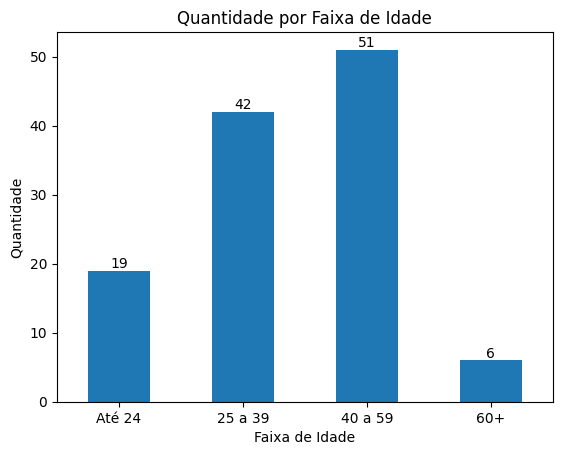

In [37]:
# Cria um gráfico com a quantidade de registros por faixa etária,
# facilitando a visualização da distribuição dos clientes por idade.


ordem = ['Até 24', '25 a 39', '40 a 59', '60+']

contagem = Base_dados['faixa_idade'].value_counts().reindex(ordem)

ax = contagem.plot(kind='bar')

ax.bar_label(ax.containers[0])

plt.title('Quantidade por Faixa de Idade')
plt.xlabel('Faixa de Idade')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

In [38]:
# Converte o horário da transação e extrai apenas a hora (0 a 23),
# criando a coluna 'hora' para análises por faixa horária.

Base_dados['hora'] = pd.to_datetime(
    Base_dados['hora_transacao'],
    format='%H:%M:%S'
).dt.hour

In [39]:
# Agrupa as horas das transações em períodos do dia
# para facilitar a análise de concentração por faixa horária.

Base_dados['faixa_horario'] = np.select(
    [
        Base_dados['hora'].between(0, 5),
        Base_dados['hora'].between(6, 11),
        Base_dados['hora'].between(12, 17),
        Base_dados['hora'].between(18, 23)
    ],
    [
        'Madrugada',
        'Manhã',
        'Tarde',
        'Noite'
    ],
    default='Não informado'
)

Base_dados[['hora', 'faixa_horario']].head(20)

,hora,faixa_horario
0,1,Madrugada
1,5,Madrugada
2,22,Noite
3,22,Noite
4,1,Madrugada
5,3,Madrugada
6,5,Madrugada
7,22,Noite
8,23,Noite
9,4,Madrugada


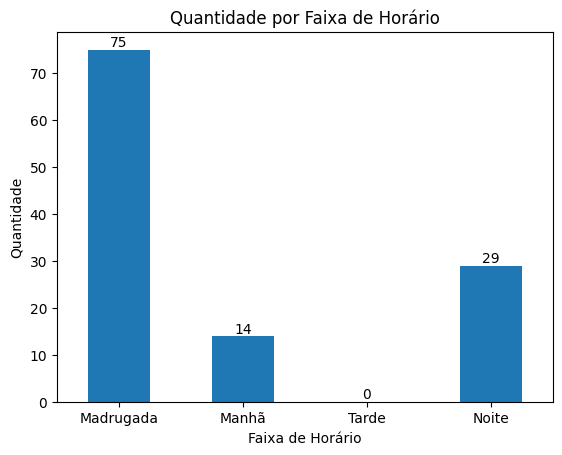

In [40]:
# Cria um gráfico com a quantidade de transações por faixa de horário,
# facilitando a identificação dos períodos com maior concentração.

ordem = ['Madrugada', 'Manhã', 'Tarde', 'Noite']

contagem = Base_dados['faixa_horario'].value_counts().reindex(ordem)

ax = contagem.plot(kind='bar')

ax.bar_label(ax.containers[0])

plt.title('Quantidade por Faixa de Horário')
plt.xlabel('Faixa de Horário')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

In [41]:
# Converte a data da transação e cria o dia da semana em português,
# permitindo analisar a distribuição das contestações ao longo da semana.

Base_dados['data_transacao'] = pd.to_datetime(Base_dados['data_transacao'], errors='coerce')

Base_dados['dia_semana'] = Base_dados['data_transacao'].dt.day_name()

dias = {
    'Monday': 'Segunda-feira',
    'Tuesday': 'Terça-feira',
    'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira',
    'Friday': 'Sexta-feira',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

Base_dados['dia_semana'] = Base_dados['data_transacao'].dt.day_name().map(dias)

## 4. Investigação de Padrões e Possíveis Ataques

Análise temporal e comportamental das contestações para identificar concentrações atípicas, estabelecimentos, adquirentes, regiões e horários que merecem investigação.

In [42]:
# Cria um painel interativo para analisar contestações por data,
# período, métrica e diferentes dimensões do perfil transacional.



# -----------------------------
# FILTROS
# -----------------------------

filtro_data = widgets.Dropdown(
    options=['data_contestacao', 'data_transacao'],
    description='Data:'
)

filtro_periodo = widgets.Dropdown(
    options=['Mês', 'Dia'],
    description='Período:'
)

filtro_metrica = widgets.Dropdown(
    options=[
        'Quantidade de transações',
        'Quantidade de clientes',
        'Valor contestado'
    ],
    description='Métrica:'
)

filtro_quebra = widgets.Dropdown(
    options=[
        'modalidade_fraude',
        'regiao',
        'uf',
        'segmento',
        'faixa_idade',
        'faixa_horario',
        'canal_abertura',
        'dia_semana',
        'estabelecimento',
        'adquirente',
        'hora'
    ],
    description='Quebra:'
)

saida = widgets.Output()


# -----------------------------
# FUNÇÃO DO GRÁFICO
# -----------------------------

def atualizar_grafico(change=None):

    with saida:
        clear_output(wait=True)

        # Faz uma cópia para não alterar a base original
        df = Base_dados.copy()

        data = filtro_data.value
        metrica = filtro_metrica.value
        quebra = filtro_quebra.value

        # Garante que a coluna escolhida esteja no formato de data
        df[data] = pd.to_datetime(df[data], errors='coerce')


        # Define se o agrupamento será mensal ou diário
        if filtro_periodo.value == 'Mês':
            df['periodo'] = df[data].dt.to_period('M')

        else:
            # Mantém a data completa para análise diária
            df['periodo'] = df[data].dt.normalize()


        # -----------------------------
        # CÁLCULO DA MÉTRICA
        # -----------------------------

        if metrica == 'Quantidade de transações':

            tabela = (
                df.groupby(['periodo', quebra])
                .size()
                .unstack(fill_value=0)
            )

        elif metrica == 'Quantidade de clientes':

            tabela = (
                df.groupby(['periodo', quebra])['cpf']
                .nunique()
                .unstack(fill_value=0)
            )

        else:

            tabela = (
                df.groupby(['periodo', quebra])['transacao_contestada_valor']
                .sum()
                .unstack(fill_value=0)
            )


        # -----------------------------
        # TAMANHO DO GRÁFICO
        # -----------------------------

        if filtro_periodo.value == 'Dia':

            # A largura aumenta conforme a quantidade de dias
            # para permitir uma data abaixo de cada barra
            tamanho = (max(22, len(tabela.index) * 0.35), 8)

        else:
            tamanho = (14, 7)


        # Cria o gráfico de barras empilhadas
        ax = tabela.plot(
            kind='bar',
            stacked=True,
            figsize=tamanho
        )


        # -----------------------------
        # VALORES NAS BARRAS
        # -----------------------------

        for container in ax.containers:

            if filtro_periodo.value == 'Dia':

                # No gráfico diário mostra apenas valores >= 2
                # para não poluir com vários números "1"
                labels = [
                    f'{valor:.0f}' if valor >= 2 else ''
                    for valor in container.datavalues
                ]

                ax.bar_label(
                    container,
                    labels=labels,
                    label_type='center'
                )

            else:

                ax.bar_label(
                    container,
                    label_type='center',
                    fmt='%.0f'
                )


        # -----------------------------
        # TÍTULO E EIXOS
        # -----------------------------

        plt.xlabel(filtro_periodo.value)
        plt.ylabel(metrica)

        plt.title(
            f'{metrica} por {filtro_periodo.value.lower()} — {quebra}'
        )


        # -----------------------------
        # DATAS DO EIXO X
        # -----------------------------

        if filtro_periodo.value == 'Dia':

            # Mostra uma data para cada barra
            ax.set_xticks(range(len(tabela.index)))

            ax.set_xticklabels(
                [
                    data.strftime('%d/%m/%Y')
                    for data in tabela.index
                ],
                rotation=90,
                fontsize=8
            )

        else:

            plt.xticks(rotation=45)


        # Legenda
        plt.legend(title=quebra, loc='upper right')

        # Ajusta os espaços automaticamente
        plt.tight_layout()

        # Exibe o gráfico
        plt.show()


# -----------------------------
# ATUALIZA AUTOMATICAMENTE
# -----------------------------

filtro_data.observe(atualizar_grafico, names='value')
filtro_periodo.observe(atualizar_grafico, names='value')
filtro_metrica.observe(atualizar_grafico, names='value')
filtro_quebra.observe(atualizar_grafico, names='value')


# Exibe os filtros e o gráfico
display(
    filtro_data,
    filtro_periodo,
    filtro_metrica,
    filtro_quebra,
    saida
)

# Gera o primeiro gráfico
atualizar_grafico()

Dropdown(description='Data:', options=('data_contestacao', 'data_transacao'), value='data_contestacao')

Dropdown(description='Período:', options=('Mês', 'Dia'), value='Mês')

Dropdown(description='Métrica:', options=('Quantidade de transações', 'Quantidade de clientes', 'Valor contest…

Dropdown(description='Quebra:', options=('modalidade_fraude', 'regiao', 'uf', 'segmento', 'faixa_idade', 'faix…

Output()

Análise: há indício de possível ataque/padrão coordenado, mas a concentração sozinha não confirma um ataque. O comportamento suspeito começa em 30/03 e atinge o pico em 06/04, com 4 transações no dia; entre 30/03 e 06/04 foram 12 contestações de 12 clientes, somando cerca de R$ 13,3 mil. Todas as transações foram online, concentradas principalmente em Noite/Madrugada (10 de 12 casos), na região Sudeste (9 casos), com destaque para SP (4) e ES (3). Os estabelecimentos mais presentes foram Steam (5 casos), Eletrônicos Y (3) e Mercado Livre (3), enquanto a Stone foi a adquirente mais concentrada, com 5 casos. A modalidade predominante foi Compra não reconhecida (5 casos). Não há um único público claramente dominante, embora as faixas 25–39 anos (4 casos), até 24 (3) e 40–59 (3) concentrem a maior parte. Os relatos dos clientes são compatíveis com as modalidades registradas, reforçando que essa concentração merece investigação, embora ainda não seja suficiente para afirmar que houve um ataque.

**Hipótese 1** — Ataque concentrado em curto período
**Evidência:** 12 contestações entre 30/03 e 06/04, com pico de 4 casos em 06/04.
**Filtro:** *data_transacao | Dia | Quantidade de transações | modalidade_fraude*
**Conclusão:** existe concentração temporal fora do padrão e merece investigação.

**Hipótese 2** — Concentração em determinados estabelecimentos/adquirentes
**Evidência:** destaque para Steam, Eletrônicos Y, Mercado Livre e maior presença da Stone.
**Filtro:** *data_transacao | Dia | Quantidade de transações | estabelecimento e depois adquirente.*
**Conclusão:** A concentração em determinados estabelecimentos e adquirentes pode indicar um ponto em comum nas transações fraudulentas, que deve ser investigado

**Hipótese 3** — Fraudes online em horários de maior risco
**Evidência:** predominância de transações online, principalmente em Noite/Madrugada, com forte presença no Sudeste.
**Filtro:** *data_transacao | Dia | Quantidade de transações | faixa_horario, depois regiao.*
**Conclusão:** o padrão de horário, canal e localização pode indicar comportamento coordenado, mas não comprova ataque isoladamente.

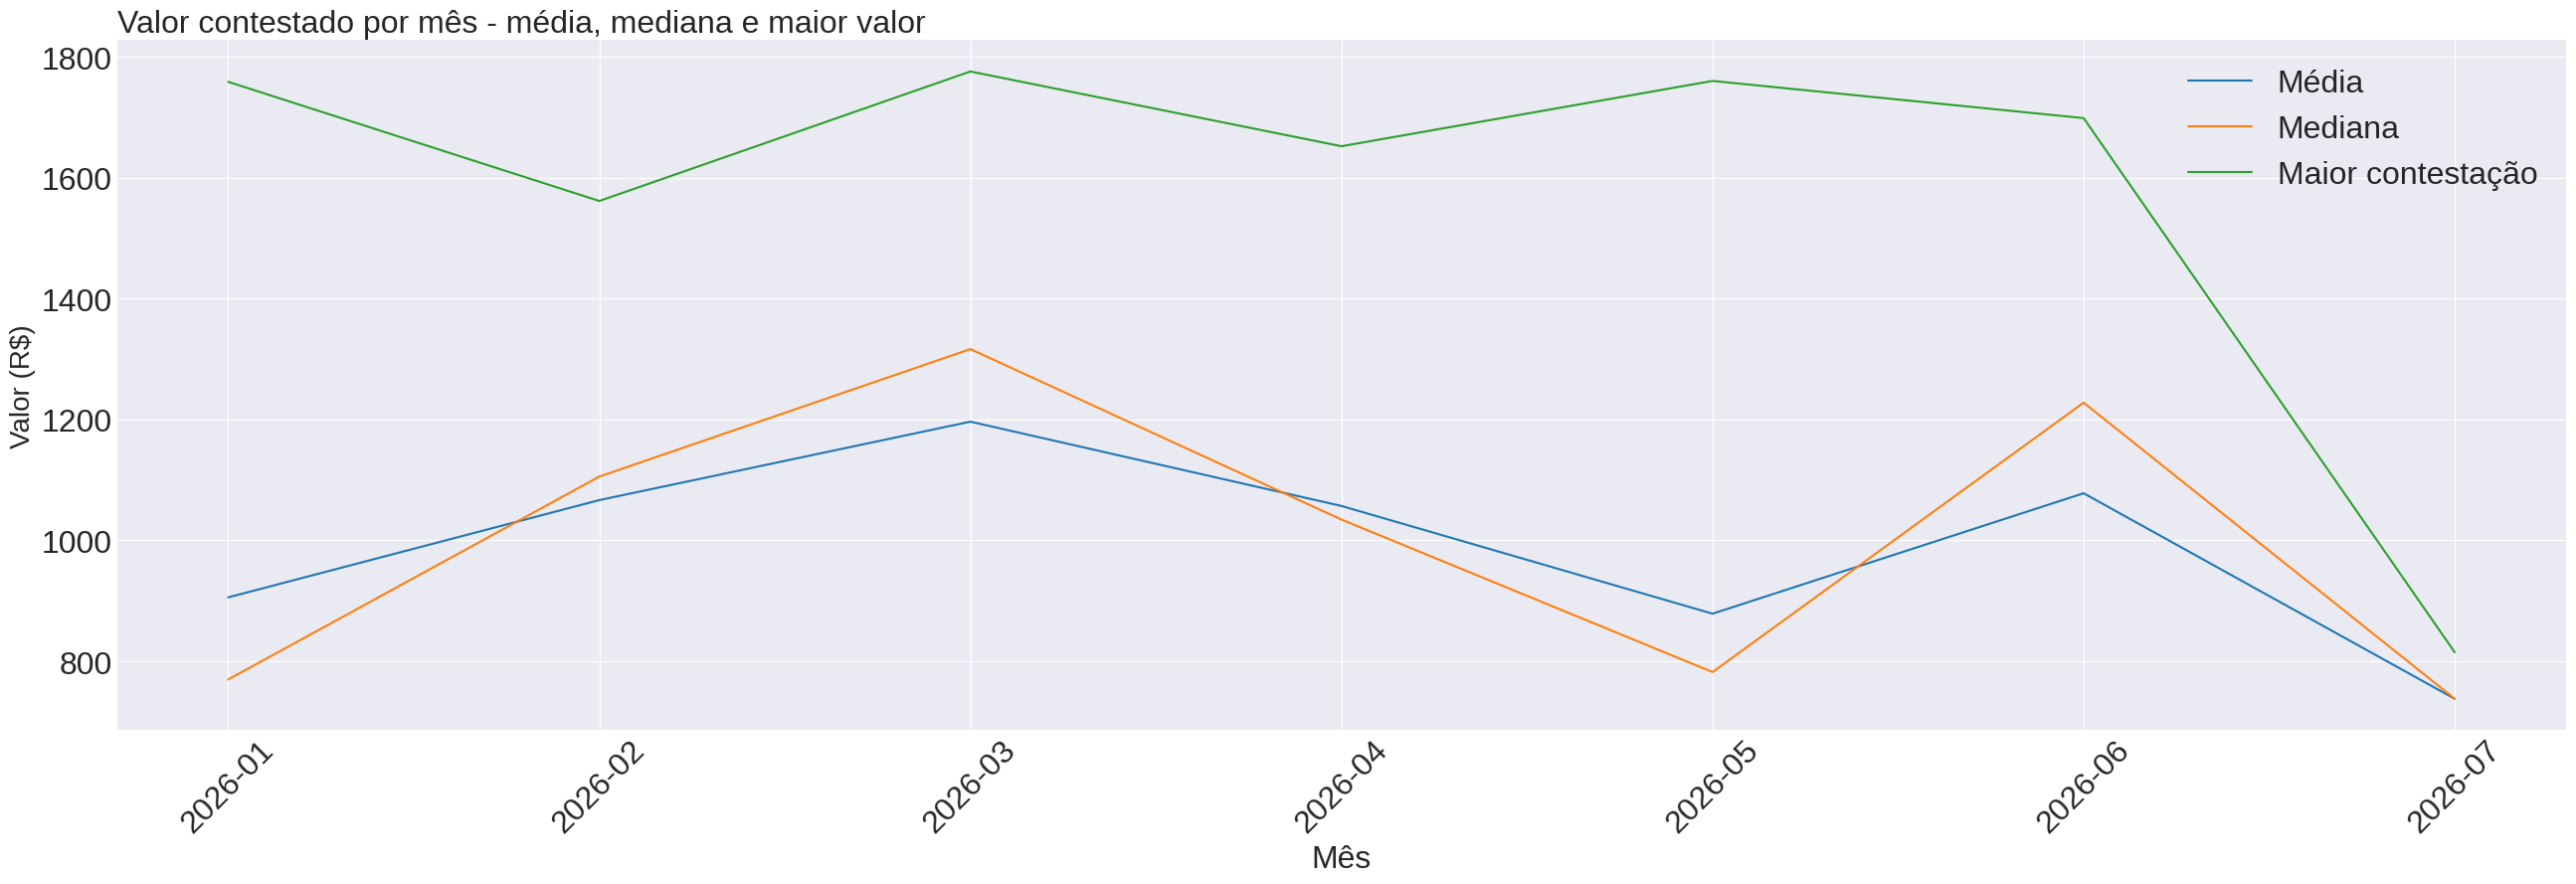

In [43]:
# Analisa a evolução mensal dos valores contestados,
# comparando média, mediana e maior valor registrado em cada mês.

# escolher a coluna de data
Base_dados['data_contestacao'] = pd.to_datetime(Base_dados['data_contestacao'], errors='coerce')

# agrupar por mês
grafico = Base_dados.groupby(Base_dados['data_contestacao'].dt.to_period('M'))['transacao_contestada_valor'].agg(
    Media='mean',
    Mediana='median',
    Maior='max'
)

grafico.index = grafico.index.astype(str)

plt.style.use('seaborn-v0_8-darkgrid')

# Aumenta o tamanho geral do gráfico
plt.figure(figsize=(26, 9))

# Aumenta o tamanho do título
plt.title('Valor contestado por mês - média, mediana e maior valor', fontsize=23, loc='left')

plt.plot(grafico.index, grafico['Media'], label='Média')
plt.plot(grafico.index, grafico['Mediana'], label='Mediana')
plt.plot(grafico.index, grafico['Maior'], label='Maior contestação')

# Aumenta o tamanho da legenda
plt.legend(fontsize=23)

# Aumenta o tamanho dos nomes dos eixos
plt.xlabel('Mês', fontsize=23)
plt.ylabel('Valor (R$)', fontsize=20)

# Aumenta o tamanho dos textos dos eixos
plt.xticks(rotation=45, fontsize=23)
plt.yticks(fontsize=23)

plt.tight_layout()
plt.show()

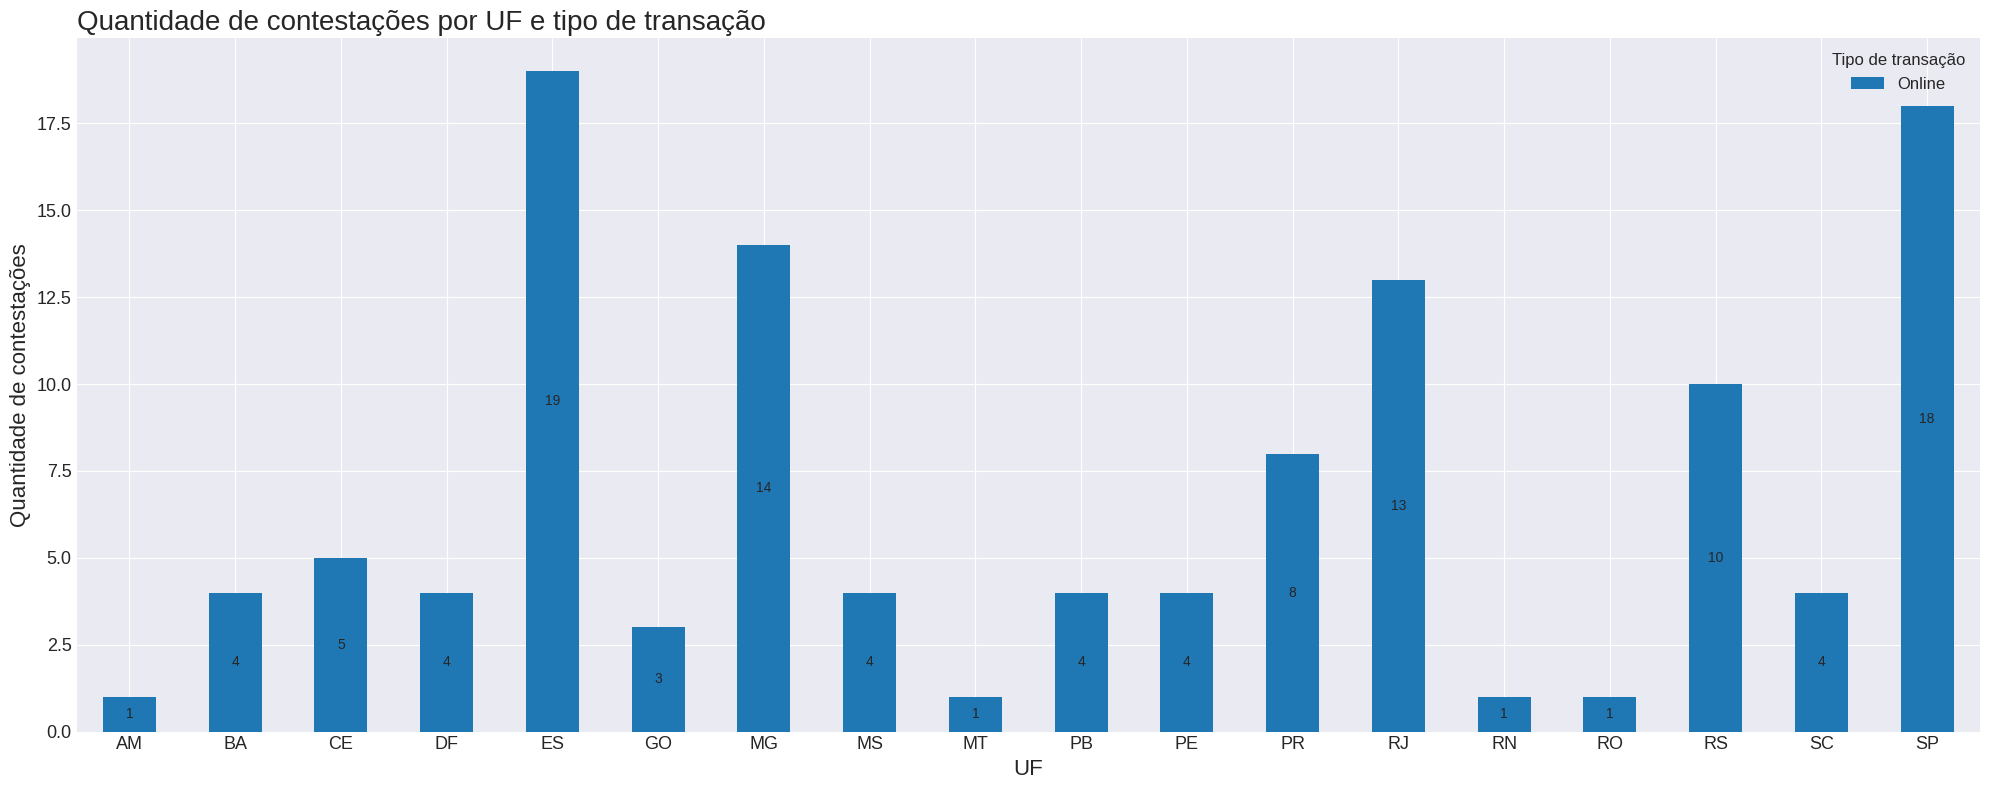

In [44]:
# Analisa a quantidade de contestações por UF e tipo de transação,
# permitindo verificar a concentração geográfica dos registros.

# Agrupa os registros por UF e tipo de transação
# Cada célula representa a quantidade de contestações
grafico_uf = (
    Base_dados
    .groupby(['uf', 'tipo_transacao'])
    .size()
    .unstack(fill_value=0)
)

# Define o tamanho do gráfico
ax = grafico_uf.plot(
    kind='bar',
    stacked=True,
    figsize=(20, 8)
)

# Mostra a quantidade dentro de cada parte das barras
for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fontsize=10
    )

# Título
plt.title(
    'Quantidade de contestações por UF e tipo de transação',
    fontsize=20,
    loc='left'
)

# Configuração dos eixos
plt.xlabel('UF', fontsize=16)
plt.ylabel('Quantidade de contestações', fontsize=16)

# Tamanho dos textos dos eixos
plt.xticks(rotation=0, fontsize=13)
plt.yticks(fontsize=13)

# Legenda
plt.legend(
    title='Tipo de transação',
    fontsize=12,
    title_fontsize=12
)

# Ajusta automaticamente os espaços
plt.tight_layout()

# Exibe o gráfico
plt.show()

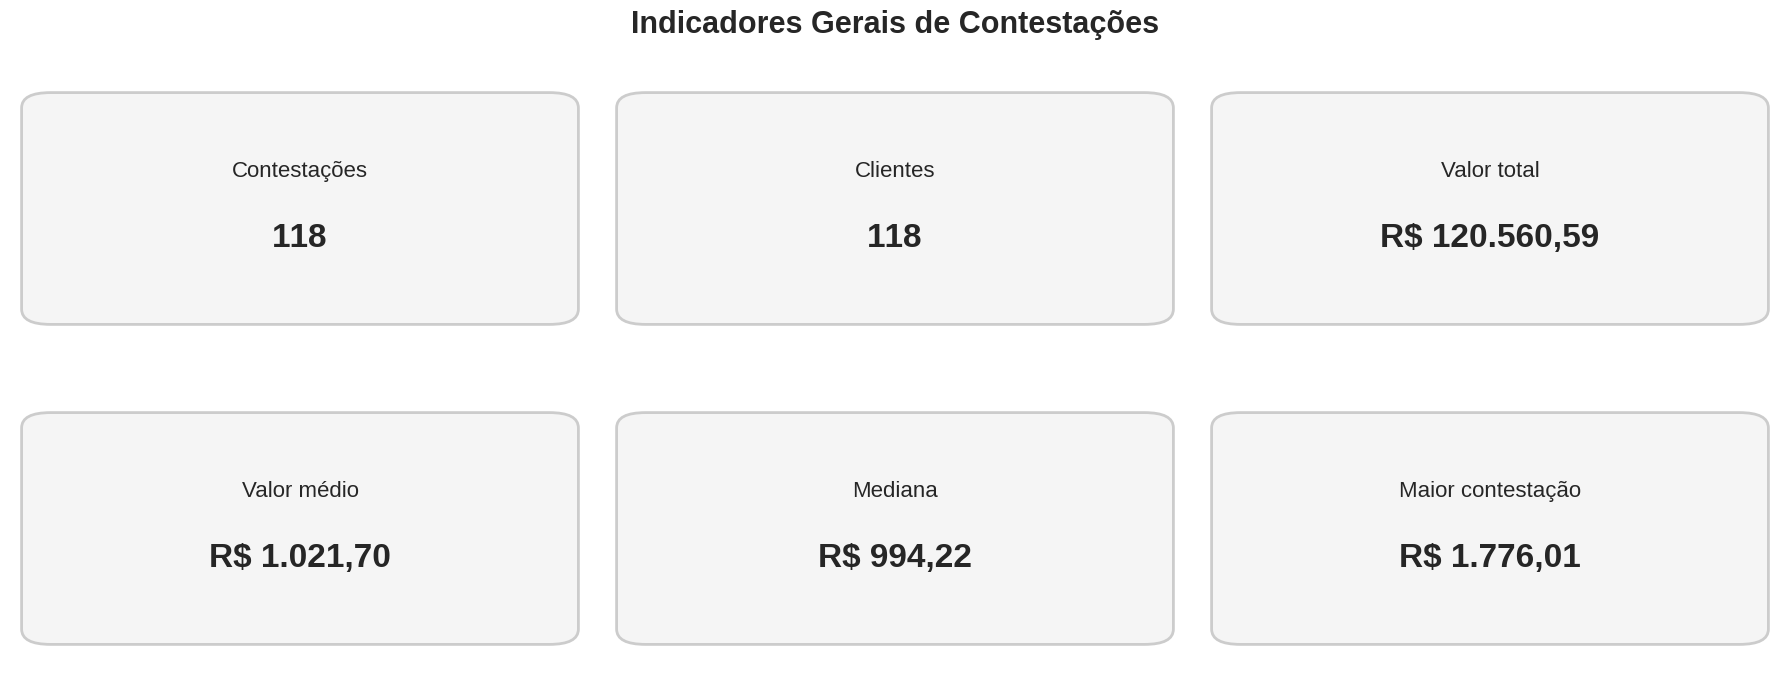

In [45]:
# Calcula e exibe os principais indicadores gerais das contestações,
# incluindo volume de casos, clientes e valores financeiros.


# Função para formatar moeda no padrão brasileiro
def formatar_moeda_br(valor):
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# Calcula os indicadores
qtd_contestacoes = Base_dados['numero_ticket'].nunique()
qtd_clientes = Base_dados['cpf'].nunique()
valor_total = Base_dados['transacao_contestada_valor'].sum()
valor_medio = Base_dados['transacao_contestada_valor'].mean()
mediana = Base_dados['transacao_contestada_valor'].median()
maior_contestacao = Base_dados['transacao_contestada_valor'].max()

# Organiza os KPIs
indicadores = [
    ('Contestações', f'{qtd_contestacoes:,}'.replace(',', '.')),
    ('Clientes', f'{qtd_clientes:,}'.replace(',', '.')),
    ('Valor total', formatar_moeda_br(valor_total)),
    ('Valor médio', formatar_moeda_br(valor_medio)),
    ('Mediana', formatar_moeda_br(mediana)),
    ('Maior contestação', formatar_moeda_br(maior_contestacao))
]

# Cria 6 áreas para os cards
fig, axes = plt.subplots(2, 3, figsize=(18, 7))

for ax, (titulo, valor) in zip(axes.flatten(), indicadores):

    # Remove os eixos tradicionais
    ax.axis('off')

    # Cria o fundo arredondado do card
    card = FancyBboxPatch(
        (0.05, 0.15),
        0.90,
        0.70,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        facecolor='#f5f5f5',
        edgecolor='#cccccc',
        linewidth=2
    )

    ax.add_patch(card)

    # Título do KPI
    ax.text(
        0.5, 0.62,
        titulo,
        ha='center',
        va='center',
        fontsize=16
    )

    # Valor principal do KPI
    ax.text(
        0.5, 0.40,
        valor,
        ha='center',
        va='center',
        fontsize=24,
        fontweight='bold'
    )

# Título geral do painel
fig.suptitle(
    'Indicadores Gerais de Contestações',
    fontsize=22,
    fontweight='bold'
)

# Ajusta os espaços entre os cards
plt.tight_layout()

plt.show()

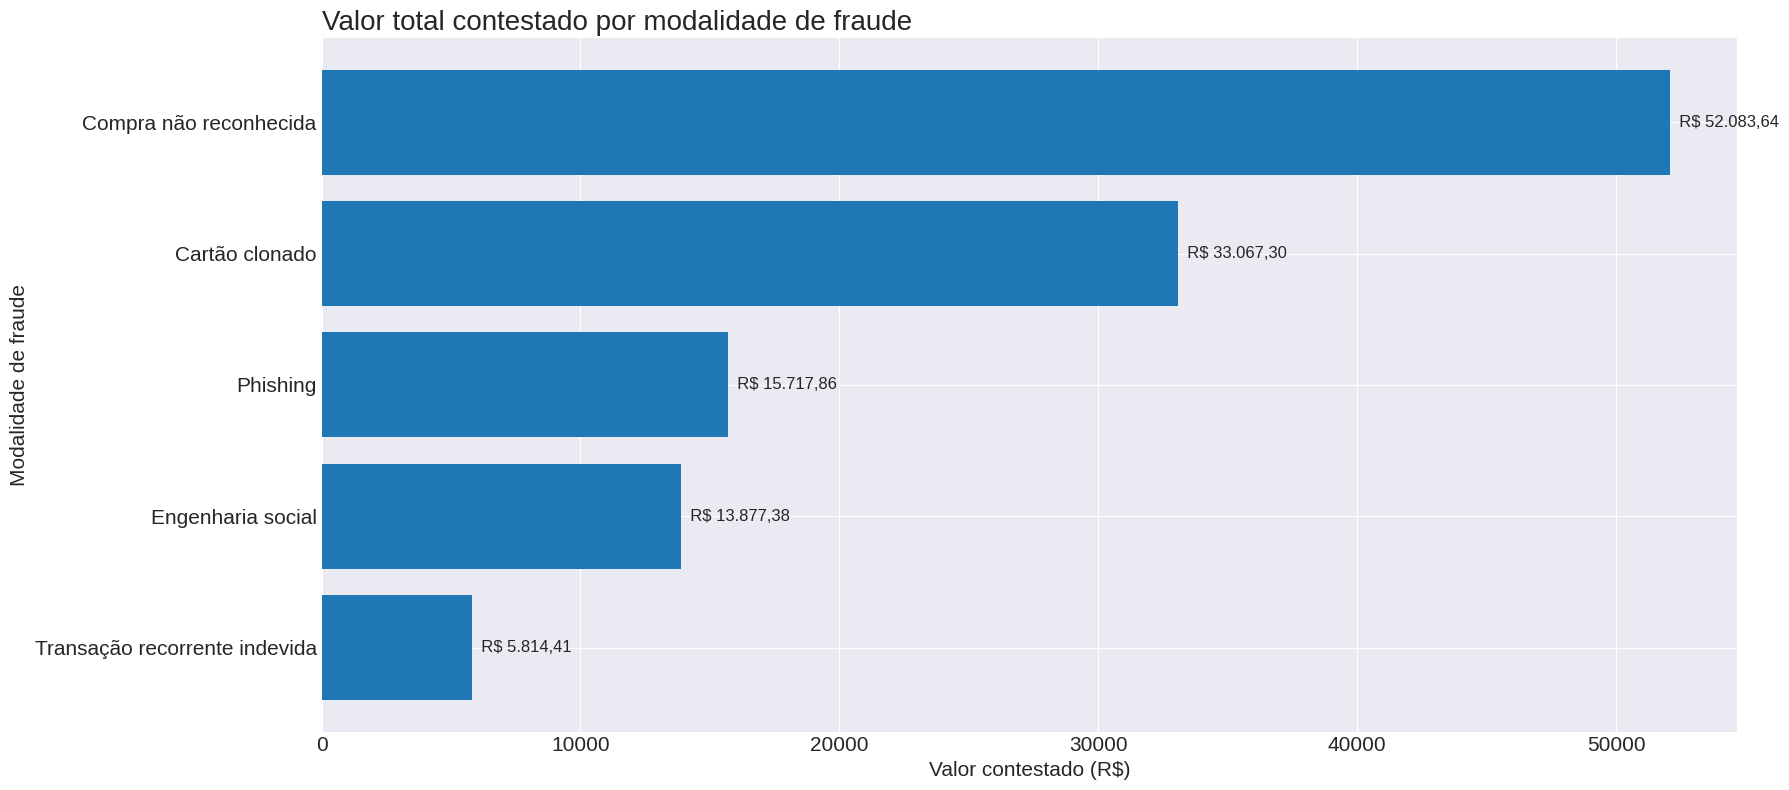

In [46]:
# Soma o valor contestado por modalidade de fraude
# e exibe a concentração financeira em um gráfico de barras horizontais.

# Soma todo o valor contestado dentro de cada modalidade de fraude
valor_modalidade = (
    Base_dados
    .groupby('modalidade_fraude')['transacao_contestada_valor']
    .sum()
    .sort_values()
)

# Define o tamanho do gráfico
fig, ax = plt.subplots(figsize=(18, 8))

# Cria barras horizontais para facilitar a leitura das modalidades
barras = ax.barh(
    valor_modalidade.index,
    valor_modalidade.values
)

# Coloca o valor em R$ ao lado de cada barra
for barra in barras:
    valor = barra.get_width()

    # Formata o número no padrão brasileiro
    valor_formatado = (
        f'R$ {valor:,.2f}'
        .replace(',', 'X')
        .replace('.', ',')
        .replace('X', '.')
    )

    ax.text(
        valor,
        barra.get_y() + barra.get_height()/2,
        f'  {valor_formatado}',
        va='center',
        fontsize=12
    )

# Título do gráfico
plt.title(
    'Valor total contestado por modalidade de fraude',
    fontsize=20,
    loc='left'
)

# Nome dos eixos
plt.xlabel('Valor contestado (R$)', fontsize=15)
plt.ylabel('Modalidade de fraude', fontsize=15)

# Aumenta os textos dos eixos
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Ajusta os espaços automaticamente
plt.tight_layout()

# Exibe o gráfico
plt.show()

## 5. Análise de Ressarcimento — Abordagem Inicial

Nesta primeira abordagem, o valor contestado é comparado ao maior valor histórico do cliente, considerando apenas transações realizadas antes da transação contestada.

In [47]:
# Cria a data e hora completas das transações históricas.
# Isso permitirá saber exatamente quais transações aconteceram antes da contestação.
Base_transacional['data_hora_transacao'] = pd.to_datetime(
    Base_transacional['data'].astype(str) + ' ' +
    Base_transacional['hora'].astype(str),
    errors='coerce'
)

# Cria a data e hora completas da transação contestada.
# Essa coluna será usada como limite para consultar o histórico anterior do cliente.
Base_dados['data_hora_contestada'] = pd.to_datetime(
    Base_dados['data_transacao'].astype(str) + ' ' +
    Base_dados['hora_transacao'].astype(str),
    errors='coerce'
)

In [48]:
# Cria uma base auxiliar ligando cada contestação ao histórico do mesmo cliente.
# Para cada numero_ticket, serão encontradas todas as transações daquele CPF.

historico_cliente = Base_dados[
    ['numero_ticket', 'cpf', 'data_hora_contestada']
].merge(
    Base_transacional[
        ['cpf_em_texto_14', 'data_hora_transacao', 'valor']
    ],
    left_on='cpf',
    right_on='cpf_em_texto_14',
    how='left'
)

# Mantém somente transações que aconteceram ANTES da transação contestada.
# Assim, transações futuras e a própria transação contestada não entram no histórico.

historico_cliente = historico_cliente[
    historico_cliente['data_hora_transacao'] <
    historico_cliente['data_hora_contestada']
]

historico_cliente.head(10)

,numero_ticket,cpf,data_hora_contestada,cpf_em_texto_14,data_hora_transacao,valor
3,TK100078,28034576107,2026-01-12 01:40:53,28034576107,2026-01-06 15:40:47,65.93
11,TK100078,28034576107,2026-01-12 01:40:53,28034576107,2026-01-07 19:38:05,47.70
59,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-03-21 12:27:12,17.58
60,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-01-14 13:20:30,60.42
61,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-05-13 07:16:27,26.21
62,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-03-27 10:44:40,16.24
63,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-05-22 21:23:36,57.79
64,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-01-03 14:19:17,11.76
65,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-03-28 18:05:04,27.11
66,TK100075,27469851011,2026-06-25 22:57:39,27469851011,2026-05-16 06:43:00,32.12


In [49]:
# Para cada contestação, identifica o maior valor que aquele cliente
# já havia transacionado ANTES da transação contestada.

maior_historico = (
    historico_cliente
    .groupby('numero_ticket')['valor']
    .max()
    .reset_index()
    .rename(columns={'valor': 'maior_valor_historico'})
)

maior_historico.head(10)

,numero_ticket,maior_valor_historico
0,TK100000,68.65
1,TK100001,137.61
2,TK100002,77.44
3,TK100003,19.06
4,TK100004,117.70
5,TK100005,100.53
6,TK100006,168.46
7,TK100007,167.13
8,TK100008,203.20
9,TK100009,46.92


In [50]:
# Traz para a Base_dados o maior valor histórico anterior de cada contestação.
# O merge é feito pelo numero_ticket para garantir que cada caso receba o histórico correto.

Base_dados = Base_dados.merge(
    maior_historico,
    on='numero_ticket',
    how='left'
)

# Exibe uma amostra para validar se o maior valor histórico
# foi associado corretamente a cada contestação.
Base_dados[
    ['numero_ticket', 'transacao_contestada_valor', 'maior_valor_historico']
].head(10)

,numero_ticket,transacao_contestada_valor,maior_valor_historico
0,TK100078,499.68,65.93
1,TK100082,766.57,NaN
2,TK100075,1227.99,143.93
3,TK100076,1128.70,40.69
4,TK100073,1026.18,88.43
5,TK100009,1216.50,46.92
6,TK100030,1125.89,73.74
7,TK100104,1589.75,104.70
8,TK100070,1254.76,161.99
9,TK100055,1221.22,70.59


In [51]:
# Compara o valor contestado com o maior valor histórico anterior do cliente.
# Exemplo: 1.5 significa que a contestação foi 50% maior que o maior valor histórico.

Base_dados['percentual_maior_historico'] = (
    Base_dados['transacao_contestada_valor'] /
    Base_dados['maior_valor_historico']
)

In [52]:
# Aplica a regra inicial de ressarcimento com base no maior valor histórico anterior:
# - Sem histórico: cliente não possui transação anterior para comparação.
# - Pagar: valor contestado é maior que o maior valor histórico anterior.
# - Não pagar: valor contestado está dentro do histórico já observado.

def definir_ressarcimento(linha):
    if pd.isna(linha['maior_valor_historico']):
        return 'Sem histórico'
    elif linha['percentual_maior_historico'] > 1:
        return 'Pagar'
    else:
        return 'Não pagar'

Base_dados['decisao_ressarcimento'] = Base_dados.apply(
    definir_ressarcimento,
    axis=1
)

# Confere quantos casos ficaram em cada decisão
Base_dados['decisao_ressarcimento'].value_counts()

,count
decisao_ressarcimento,
Pagar,117
Sem histórico,1


Minha regra considera uma transação fora do perfil quando o valor contestado é maior que o maior valor já transacionado anteriormente pelo cliente. Nesse caso, a transação é classificada como “Pagar”. Quando o valor está dentro do histórico já observado, a decisão é “Não pagar”. Caso não exista histórico anterior suficiente para comparação, o caso é classificado como “Sem histórico”.

## 6. Evolução da Regra de Ressarcimento

A abordagem inicial foi refinada com o uso de P90 e P99 para representar melhor o comportamento histórico dos clientes e reduzir a influência de valores extremos isolados.

In [53]:
# Calcula o P90, P99 e a quantidade de transações anteriores para cada contestação.
# Como historico_cliente já contém somente transações anteriores ao evento contestado,
# os percentis representam apenas o comportamento conhecido do cliente até aquele momento.

perfil_historico = (
    historico_cliente
    .groupby('numero_ticket')['valor']
    .agg(
        # Até este valor estão aproximadamente 90% das transações anteriores.
        p90_historico=lambda x: x.quantile(0.90),

        # Até este valor estão aproximadamente 99% das transações anteriores.
        p99_historico=lambda x: x.quantile(0.99),

        # Quantidade de transações anteriores utilizadas para construir o perfil.
        qtde_transacoes_historico='count'
    )
    .reset_index()
)

perfil_historico.head(10)

,numero_ticket,p90_historico,p99_historico,qtde_transacoes_historico
0,TK100000,57.380,68.0996,17
1,TK100001,79.132,123.8340,29
2,TK100002,63.400,76.0360,7
3,TK100003,18.016,18.9556,3
4,TK100004,100.150,117.6088,25
5,TK100005,75.106,96.7684,17
6,TK100006,84.954,154.9248,29
7,TK100007,104.600,156.3266,20
8,TK100008,126.104,195.4904,9
9,TK100009,44.028,46.6308,4


In [54]:
# Adiciona à Base_dados o P90, P99 e a quantidade de transações históricas
# calculados anteriormente para cada contestação.
# O cruzamento é feito pelo numero_ticket, pois cada ticket representa
# uma transação contestada específica.

Base_dados = Base_dados.merge(
    perfil_historico,
    on='numero_ticket',
    how='left'
)

# Confere se as novas informações foram adicionadas corretamente.
Base_dados[
    [
        'numero_ticket',
        'transacao_contestada_valor',
        'p90_historico',
        'p99_historico',
        'qtde_transacoes_historico'
    ]
].head(10)

,numero_ticket,transacao_contestada_valor,p90_historico,p99_historico,qtde_transacoes_historico
0,TK100078,499.68,64.107,65.7477,2.0
1,TK100082,766.57,NaN,NaN,NaN
2,TK100075,1227.99,77.721,127.1970,30.0
3,TK100076,1128.70,35.506,40.1716,9.0
4,TK100073,1026.18,74.201,87.0071,10.0
5,TK100009,1216.50,44.028,46.6308,4.0
6,TK100030,1125.89,57.860,71.6984,17.0
7,TK100104,1589.75,76.973,99.9876,18.0
8,TK100070,1254.76,114.224,160.6484,25.0
9,TK100055,1221.22,63.634,69.8944,5.0


In [55]:
# Verifica a quantidade de transações históricas disponível em cada caso,
# ajudando a definir quando P90/P99 possuem histórico suficiente para uso.

print('Menos de 5 transações:',
      (Base_dados['qtde_transacoes_historico'] < 5).sum())

print('De 5 a 9 transações:',
      Base_dados['qtde_transacoes_historico'].between(5, 9).sum())

print('10 ou mais transações:',
      (Base_dados['qtde_transacoes_historico'] >= 10).sum())

print('Sem histórico:',
      Base_dados['qtde_transacoes_historico'].isna().sum())

Menos de 5 transações: 17
De 5 a 9 transações: 26
10 ou mais transações: 74
Sem histórico: 1


**Critério para escolha da regra:**  
Clientes com 10 ou mais transações possuem histórico suficiente para aplicação de P90/P99. Para históricos menores, o maior valor anterior é utilizado como referência.

In [56]:
# Cria a regra FINAL de ressarcimento usando duas estratégias:
#
# 1. Clientes com 10 ou mais transações anteriores:
#    usa P90 e P99, pois existe histórico suficiente para analisar o perfil.
#
# 2. Clientes com menos de 10 transações anteriores:
#    usa o maior valor histórico como referência, pois P90/P99
#    seriam pouco confiáveis com poucas observações.
#
# 3. Clientes sem nenhuma transação anterior:
#    ficam como "Sem histórico" para análise manual.


def definir_ressarcimento_final(linha):

    # Não existe nenhuma transação anterior do cliente.
    if pd.isna(linha['qtde_transacoes_historico']):
        return 'Sem histórico'

    # HISTÓRICO SUFICIENTE: 10 ou mais transações anteriores.
    if linha['qtde_transacoes_historico'] >= 10:

        # Acima do P99 = valor extremamente fora do perfil.
        if linha['transacao_contestada_valor'] > linha['p99_historico']:
            return 'Pagar'

        # Acima do P90, mas abaixo ou igual ao P99 = comportamento incomum.
        elif linha['transacao_contestada_valor'] > linha['p90_historico']:
            return 'Revisar'

        # Até o P90 = dentro do comportamento habitual.
        else:
            return 'Não pagar'

    # HISTÓRICO LIMITADO: entre 1 e 9 transações anteriores.
    # Nesse caso, compara o valor contestado com a maior transação anterior.
    else:

        if linha['transacao_contestada_valor'] > linha['maior_valor_historico']:
            return 'Pagar'
        else:
            return 'Não pagar'


# Aplica a regra em todas as contestações.
Base_dados['decisao_ressarcimento_final'] = Base_dados.apply(
    definir_ressarcimento_final,
    axis=1
)

# Mostra quantos casos ficaram em cada decisão.
Base_dados['decisao_ressarcimento_final'].value_counts()

,count
decisao_ressarcimento_final,
Pagar,117
Sem histórico,1


**Regra final:**  
10 ou mais transações históricas: usa P90 e P99 para avaliar o perfil.  
De 1 a 9 transações históricas: usa o maior valor histórico como referência.  
Sem histórico anterior: classifica como "Sem histórico".

**Resultado:**  
"Pagar" quando a transação está fora do perfil definido pela regra.  
"Não pagar" quando está dentro do perfil.  
"Revisar" quando o valor está entre P90 e P99.

## 7. Comparação dos Modelos e Resultado Final

Comparação entre maior valor histórico, P90 e P99, seguida da aplicação da regra final e consolidação dos resultados de ressarcimento.

In [57]:
# Compara a transação contestada com três formas diferentes
# de representar o comportamento histórico do cliente:
#
# Modelo 1 = maior valor histórico
# Modelo 2 = P90
# Modelo 3 = P99
#
# "Fora do perfil" significa que o valor contestado ultrapassou
# o limite definido por aquele modelo.

def comparar_modelo(valor_contestado, limite):

    # Se não existir histórico suficiente para calcular o limite,
    # não é possível classificar a transação.
    if pd.isna(limite):
        return 'Sem histórico'

    # Se o valor contestado ultrapassar o limite,
    # a transação é considerada fora do perfil.
    elif valor_contestado > limite:
        return 'Fora do perfil'

    # Caso contrário, está dentro do comportamento observado.
    else:
        return 'Dentro do perfil'


# Modelo 1: compara com a maior transação histórica.
Base_dados['modelo_maior_historico'] = Base_dados.apply(
    lambda linha: comparar_modelo(
        linha['transacao_contestada_valor'],
        linha['maior_valor_historico']
    ),
    axis=1
)

# Modelo 2: compara com o P90.
Base_dados['modelo_p90'] = Base_dados.apply(
    lambda linha: comparar_modelo(
        linha['transacao_contestada_valor'],
        linha['p90_historico']
    ),
    axis=1
)

# Modelo 3: compara com o P99.
Base_dados['modelo_p99'] = Base_dados.apply(
    lambda linha: comparar_modelo(
        linha['transacao_contestada_valor'],
        linha['p99_historico']
    ),
    axis=1
)


# Mostra quantos casos cada modelo classificou em cada categoria.
print('MODELO 1 - MAIOR HISTÓRICO')
print(Base_dados['modelo_maior_historico'].value_counts())

print('\nMODELO 2 - P90')
print(Base_dados['modelo_p90'].value_counts())

print('\nMODELO 3 - P99')
print(Base_dados['modelo_p99'].value_counts())

MODELO 1 - MAIOR HISTÓRICO
modelo_maior_historico
Fora do perfil    117
Sem histórico       1
Name: count, dtype: int64

MODELO 2 - P90
modelo_p90
Fora do perfil    117
Sem histórico       1
Name: count, dtype: int64

MODELO 3 - P99
modelo_p99
Fora do perfil    117
Sem histórico       1
Name: count, dtype: int64


**Comparação dos modelos:**  
Os três modelos identificaram os mesmos 117 casos como fora do perfil.

O maior histórico é simples, mas pode ser influenciado por uma transação isolada muito alta.  
O P90 representa melhor o comportamento habitual, porém pode ser sensível demais para fraude.  
O P99 é mais conservador e identifica valores realmente extremos em relação ao histórico.

Por isso, entre os três modelos, o P99 parece mais adequado para identificar uma transação potencialmente fraudulenta quando existe histórico suficiente.

In [58]:
# Cria a tabela final com os principais dados utilizados na análise
# e na decisão de ressarcimento.

tabela_final = Base_dados[
    [
        'numero_ticket',
        'cpf',
        'transacao_contestada_valor',
        'maior_valor_historico',
        'p90_historico',
        'p99_historico',
        'decisao_ressarcimento_final'
    ]
].copy()


# Cria a coluna que indica se a transação ficou fora do perfil histórico.
# Pagar = fora do perfil
# Não pagar = dentro do perfil
# Revisar = caso intermediário
# Sem histórico = não foi possível classificar
tabela_final['fora_do_perfil'] = tabela_final[
    'decisao_ressarcimento_final'
].map({
    'Pagar': 'Sim',
    'Não pagar': 'Não',
    'Revisar': 'Revisar',
    'Sem histórico': 'Sem histórico'
})


# Renomeia as colunas para facilitar a leitura e apresentação dos resultados.
tabela_final = tabela_final.rename(columns={
    'numero_ticket': 'Ticket',
    'cpf': 'Cliente',
    'transacao_contestada_valor': 'Valor contestado',
    'maior_valor_historico': 'Maior histórico',
    'p90_historico': 'P90',
    'p99_historico': 'P99',
    'fora_do_perfil': 'Fora do perfil?',
    'decisao_ressarcimento_final': 'Decisão'
})


# Organiza as colunas em uma ordem lógica para análise e apresentação.
tabela_final = tabela_final[
    [
        'Ticket',
        'Cliente',
        'Valor contestado',
        'Maior histórico',
        'P90',
        'P99',
        'Fora do perfil?',
        'Decisão'
    ]
]


# Exibe uma amostra da tabela final.
tabela_final.head(10)

,Ticket,Cliente,Valor contestado,Maior histórico,P90,P99,Fora do perfil?,Decisão
0,TK100078,28034576107,499.68,65.93,64.107,65.7477,Sim,Pagar
1,TK100082,01368497250,766.57,NaN,NaN,NaN,Sem histórico,Sem histórico
2,TK100075,27469851011,1227.99,143.93,77.721,127.1970,Sim,Pagar
3,TK100076,74561980393,1128.70,40.69,35.506,40.1716,Sim,Pagar
4,TK100073,03896451766,1026.18,88.43,74.201,87.0071,Sim,Pagar
5,TK100009,84536109242,1216.50,46.92,44.028,46.6308,Sim,Pagar
6,TK100030,49785310205,1125.89,73.74,57.860,71.6984,Sim,Pagar
7,TK100104,10836594215,1589.75,104.70,76.973,99.9876,Sim,Pagar
8,TK100070,68052917395,1254.76,161.99,114.224,160.6484,Sim,Pagar
9,TK100055,86195423700,1221.22,70.59,63.634,69.8944,Sim,Pagar


In [59]:
# Considera somente os casos classificados como "Pagar"
# pela regra final de decisão.
casos_pagar_final = Base_dados[
    Base_dados['decisao_ressarcimento_final'] == 'Pagar'
]


# Quantidade total de casos indicados para ressarcimento.
quantidade_casos_final = len(casos_pagar_final)


# Soma dos valores contestados nos casos indicados para ressarcimento.
valor_total_ressarcimento_final = (
    casos_pagar_final['transacao_contestada_valor'].sum()
)


# Valor médio das transações indicadas para ressarcimento.
ticket_medio_ressarcimento_final = (
    casos_pagar_final['transacao_contestada_valor'].mean()
)


# Percentual de clientes classificados para ressarcimento
# em relação ao total de clientes analisados.
percentual_clientes_final = (
    casos_pagar_final['cpf'].nunique()
    / Base_dados['cpf'].nunique()
) * 100



# Exibe os indicadores finais.
print(f'Quantidade de casos: {quantidade_casos_final}')
print(f'Valor potencial de ressarcimento: {formatar_moeda_br(valor_total_ressarcimento_final)}')
print(f'Ticket médio: {formatar_moeda_br(ticket_medio_ressarcimento_final)}')
print(f'Percentual de clientes: {percentual_clientes_final:.2f}%'.replace('.', ','))

Quantidade de casos: 117
Valor potencial de ressarcimento: R$ 119.794,02
Ticket médio: R$ 1.023,88
Percentual de clientes: 99,15%


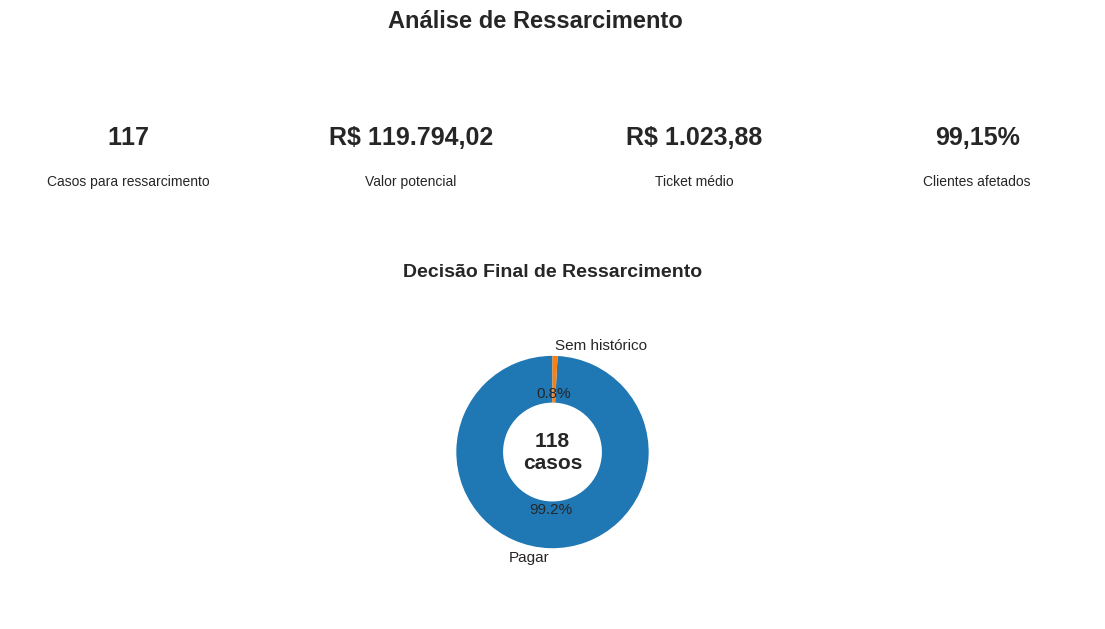

In [60]:
# Cria um painel visual com os principais indicadores
# e a distribuição das decisões finais de ressarcimento.


fig = plt.figure(figsize=(14, 7))

grid = GridSpec(
    2, 4,
    figure=fig,
    height_ratios=[1, 2.3],
    hspace=0.25
)

# Indicadores principais.
kpis = [
    ('Casos para ressarcimento', f'{quantidade_casos_final}'),
    ('Valor potencial', formatar_moeda_br(valor_total_ressarcimento_final)),
    ('Ticket médio', formatar_moeda_br(ticket_medio_ressarcimento_final)),
    ('Clientes afetados', f'{percentual_clientes_final:.2f}%'.replace('.', ','))
]

# Cria os quatro indicadores na parte superior.
for i, (titulo, valor) in enumerate(kpis):
    ax = fig.add_subplot(grid[0, i])
    ax.axis('off')

    ax.text(
        0.5, 0.60,
        valor,
        ha='center',
        va='center',
        fontsize=18,
        fontweight='bold'
    )

    ax.text(
        0.5, 0.30,
        titulo,
        ha='center',
        va='center',
        fontsize=10
    )


# Distribuição das decisões finais.
ax_grafico = fig.add_subplot(grid[1, :])

decisoes_final = Base_dados[
    'decisao_ressarcimento_final'
].value_counts()

ax_grafico.pie(
    decisoes_final.values,
    labels=decisoes_final.index,
    autopct='%1.1f%%',
    startangle=90,
    radius=0.72,
    wedgeprops={'width': 0.35},
    textprops={'fontsize': 11}
)

# Exibe o total de casos no centro da rosca.
ax_grafico.text(
    0,
    0,
    f'{decisoes_final.sum()}\ncasos',
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)

ax_grafico.set_title(
    'Decisão Final de Ressarcimento',
    fontsize=14,
    fontweight='bold'
)

fig.suptitle(
    'Análise de Ressarcimento',
    fontsize=17,
    fontweight='bold'
)

plt.show()

## 8. Limitações da Regra
A regra considera principalmente o comportamento histórico de valores do cliente e, por isso, pode gerar falsos positivos ou falsos negativos.

Uma compra legítima de valor muito acima do padrão pode ser classificada como fora do perfil. Da mesma forma, uma fraude de baixo valor pode permanecer dentro do comportamento histórico.

Clientes com pouco ou nenhum histórico também possuem menor precisão na análise. Além disso, fatores como estabelecimento, horário, localização e tipo de transação não fazem parte diretamente desta regra de decisão.

## 9. Conclusão

A análise identificou padrões relevantes de concentração temporal, regional e comportamental nas contestações, além de diferenças expressivas entre os valores contestados e o histórico transacional dos clientes.

A regra de ressarcimento evoluiu de uma comparação simples com o maior valor histórico para uma abordagem híbrida utilizando P90, P99 e quantidade de transações anteriores.

Com a regra final, 117 dos 118 casos foram classificados para ressarcimento e 1 caso permaneceu sem histórico suficiente para decisão automática.

Os resultados indicam que a combinação entre análise exploratória, comportamento histórico e regras estatísticas pode apoiar decisões mais consistentes na investigação de fraudes.